# Insights from training

This notebook looks at some of the results obtained from training.

## 1. Fixed angles performance on SV

The fixed angles are expected to perform well on random regular graph but we also used them on other graph settings. Here we take a look at the results. The notebook does the following.

1. Load all fixed-angle results (with and without re-optimization) for state vector simulations.
2. Plot their performance in terms of approximation ratio.

In [92]:
import glob
import json

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

from qaoa_parameter_setting.utils.graph_utils import maxcut_approximation_ratio

In [2]:
folders = ["random_regular", "erdos_renyi", "line_to_full"]

In [132]:
sv_fa_opt = {}
missing = set()

for folder in folders:
    sv_fa_opt[folder] = dict()
    for file_name in glob.glob(f"data/training/{folder}/*.json"):
        if "FA_SV_opt" in file_name: 
            with open(file_name, "r") as fin:
                data = json.load(fin)

            graph = data["args"]["input"].split("/")[-1]
            graph_name = graph.replace(".json", "")

            try:
                with open(f"data/minmax_cuts/{folder}/{graph_name}_maxmin_cut.json", "r") as fin:
                    minmax = json.load(fin)
            except FileNotFoundError:
                missing.add(graph)
                continue

            min_c, max_c, sum_w = minmax["min_cut"], minmax["max_cut"], minmax["sum_of_weights"]
            
            approx_ratio = maxcut_approximation_ratio(min_c, max_c, sum_w, data["1"]["energy"])
            
            sv_fa_opt[folder][graph] = {
                "angles": data["1"]["optimized_qaoa_angles"],
                "energy": data["1"]["energy"],
                "approx_ratio": approx_ratio,
            }

If minimum and maximum cut values are missing we need to compute them. Below we show how to do this.

In [182]:
missing

set()

In [165]:
sv_fa_no_opt = {}
missing = set()
skipped = set()

for folder in folders:
    sv_fa_no_opt[folder] = dict()
    for file_name in glob.glob(f"data/training/{folder}/*.json"):
        if "FA_SV_noOpt" in file_name: 
            with open(file_name, "r") as fin:
                data = json.load(fin)

            graph = data["args"]["input"].split("/")[-1]
            graph_name = graph.replace(".json", "")

            if graph not in sv_fa_opt[folder]:
                skipped.add(graph)
                continue
            
            try:
                with open(f"data/minmax_cuts/{folder}/{graph_name}_maxmin_cut.json", "r") as fin:
                    minmax = json.load(fin)
            except FileNotFoundError:
                missing.add(graph)
                continue

            min_c, max_c, sum_w = minmax["min_cut"], minmax["max_cut"], minmax["sum_of_weights"]
            
            approx_ratio = maxcut_approximation_ratio(min_c, max_c, sum_w, data["0"]["energy"])
            
            sv_fa_no_opt[folder][graph] = {
                "angles": data["0"]["optimized_qaoa_angles"],
                "energy": data["0"]["energy"],
                "approx_ratio": approx_ratio,
            }

The following instances we skipped because they did not have an equivalent in the optimized case.

In [166]:
skipped

{'000_24nodes_random3regular.json', '002_20nodes_2swap_layers.json'}

If there are missing graphs we need to run the following script in a terminal.

In [45]:
# Loop and run the script with each set of arguments
for file_name in missing:
    command = ["python", "scripts/compute_min_max_for_graph.py", "-d", "./data/minmax_cuts/", "-w", f"instances/line_to_full/{file_name}"]
    print(" ".join(command))

In [90]:
from collections import defaultdict
from qaoa_parameter_setting.utils.instance import num_nodes

from qaoa_training_pipeline.utils.graph_utils import load_graph

Now we plot the performance in terms of approximation ratio split out by the three graph families and we average over the instances in the same graph family.

In [169]:
er_depth = defaultdict(list)

for key, val in sv_fa_opt["erdos_renyi"].items():
    depth = len(val["angles"]) // 2
    er_depth[depth].append(val["approx_ratio"])

er_ps = sorted(er_depth.keys())


er_depth_no = defaultdict(list)

for key, val in sv_fa_no_opt["erdos_renyi"].items():
    depth = len(val["angles"]) // 2
    er_depth_no[depth].append(val["approx_ratio"])

er_ps_no = sorted(er_depth_no.keys())

In [170]:
rr_depth = defaultdict(list)

for key, val in sv_fa_opt["random_regular"].items():
    depth = len(val["angles"]) // 2
    rr_depth[depth].append(val["approx_ratio"])

rr_ps = sorted(rr_depth.keys())


rr_depth_no = defaultdict(list)

for key, val in sv_fa_no_opt["random_regular"].items():
    depth = len(val["angles"]) // 2
    rr_depth_no[depth].append(val["approx_ratio"])

rr_ps_no = sorted(rr_depth_no.keys())

In [171]:
lf_depth = defaultdict(list)

for key, val in sv_fa_opt["line_to_full"].items():
    depth = len(val["angles"]) // 2
    lf_depth[depth].append(val["approx_ratio"])

lf_ps = sorted(lf_depth.keys())


lf_depth_no = defaultdict(list)

for key, val in sv_fa_no_opt["line_to_full"].items():
    depth = len(val["angles"]) // 2
    lf_depth_no[depth].append(val["approx_ratio"])

lf_ps_no = sorted(lf_depth_no.keys())

The keys of `sv_fa_no_opt` and `sv_fa_opt` are the graph names. We now load these graphs and compute some of their properties like average node degree.

In [172]:
properties = defaultdict(dict)

for folder in folders:
    for key in sv_fa_opt[folder]:
        graph = load_graph(f"instances/{folder}/{key}")

        degree_list = list(deg[1] for deg in graph.degree())
        
        properties[folder][key] = (graph.order(), nx.density(graph), float(np.average(degree_list)))

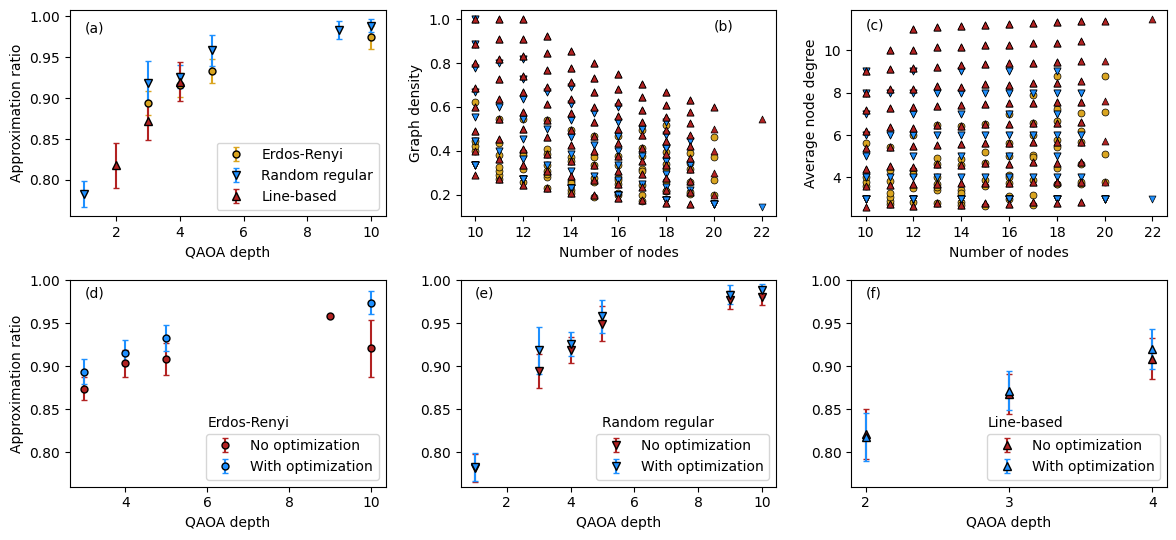

In [222]:
fig, axs = plt.subplots(2, 3, figsize=(12, 5.5))

axs = axs.flatten()

plt_opts = {"ls": "none", "ms": 5, "marker": "o", "mec": "k", "capsize": 2, "label": "Erdos-Renyi", "color": "goldenrod"}
axs[0].errorbar(er_ps, [np.average(er_depth[d]) for d in er_ps], yerr=[np.std(er_depth[d]) for d in er_ps], **plt_opts)
plt_opts = {"s": 25, "marker": "o", "ec": "k", "label": "Erdos-Renyi", "linewidth": 0.5, "color": "goldenrod"}
vals = list(properties["erdos_renyi"].values())
axs[1].scatter([v[0] for v in vals], [v[1] for v in vals], **plt_opts)
axs[2].scatter([v[0] for v in vals], [v[2] for v in vals], **plt_opts)

plt_opts = {"ls": "none", "ms": 6, "marker": "v", "mec": "k", "capsize": 2, "label": "Random regular", "color": "dodgerblue"}
axs[0].errorbar(rr_ps, [np.average(rr_depth[d]) for d in rr_ps], yerr=[np.std(rr_depth[d]) for d in rr_ps], **plt_opts)
plt_opts = {"s": 25, "marker": "v", "ec": "k", "label": "Random regular", "linewidth": 0.5, "color": "dodgerblue"}
vals = list(properties["random_regular"].values())
axs[1].scatter([v[0] for v in vals], [v[1] for v in vals], **plt_opts)
axs[2].scatter([v[0] for v in vals], [v[2] for v in vals], **plt_opts)

plt_opts = {"ls": "none", "ms": 6, "marker": "^", "mec": "k", "capsize": 2, "label": "Line-based", "color": "firebrick"}
axs[0].errorbar(lf_ps, [np.average(lf_depth[d]) for d in lf_ps], yerr=[np.std(lf_depth[d]) for d in lf_ps], **plt_opts)
plt_opts = {"s": 25, "marker": "^", "ec": "k", "label": "Line-based", "linewidth": 0.5, "color": "firebrick"}
vals = list(properties["line_to_full"].values())
axs[1].scatter([v[0] for v in vals], [v[1] for v in vals], **plt_opts)
axs[2].scatter([v[0] for v in vals], [v[2] for v in vals], **plt_opts)

axs[0].legend()
axs[0].set_xlabel("QAOA depth")
axs[0].set_ylabel("Approximation ratio")
axs[3].set_ylabel("Approximation ratio")
axs[1].set_xlabel("Number of nodes")
axs[1].set_ylabel("Graph density")
axs[2].set_xlabel("Number of nodes")
axs[2].set_ylabel("Average node degree")

plt_opts = {"ls": "none", "ms": 5, "marker": "o", "mec": "k", "capsize": 2, "color": "firebrick"}
axs[3].errorbar(er_ps_no, [np.average(er_depth_no[d]) for d in er_ps_no], yerr=[np.std(er_depth_no[d]) for d in er_ps_no], **plt_opts, label="No optimization")
plt_opts = {"ls": "none", "ms": 5, "marker": "o", "mec": "k", "capsize": 2, "color": "dodgerblue"}
axs[3].errorbar(er_ps, [np.average(er_depth[d]) for d in er_ps], yerr=[np.std(er_depth[d]) for d in er_ps], **plt_opts, label="With optimization")
axs[3].text(6, 0.83, "Erdos-Renyi")

plt_opts = {"ls": "none", "ms": 6, "marker": "v", "mec": "k", "capsize": 2, "color": "firebrick"}
axs[4].errorbar(rr_ps_no, [np.average(rr_depth_no[d]) for d in rr_ps_no], yerr=[np.std(rr_depth_no[d]) for d in rr_ps_no], **plt_opts, label="No optimization")
plt_opts = {"ls": "none", "ms": 6, "marker": "v", "mec": "k", "capsize": 2, "color": "dodgerblue"}
axs[4].errorbar(rr_ps, [np.average(rr_depth[d]) for d in rr_ps], yerr=[np.std(rr_depth[d]) for d in rr_ps], **plt_opts, label="With optimization")
#axs[4].set_title("Random regular")
axs[4].text(5, 0.83, "Random regular")

plt_opts = {"ls": "none", "ms": 6, "marker": "^", "mec": "k", "capsize": 2, "color": "firebrick"}
axs[5].errorbar(lf_ps_no, [np.average(lf_depth_no[d]) for d in lf_ps_no], yerr=[np.std(lf_depth_no[d]) for d in lf_ps_no], **plt_opts, label="No optimization")
plt_opts = {"ls": "none", "ms": 6, "marker": "^", "mec": "k", "capsize": 2, "color": "dodgerblue"}
axs[5].errorbar(lf_ps, [np.average(lf_depth[d]) for d in lf_ps], yerr=[np.std(lf_depth[d]) for d in lf_ps], **plt_opts, label="With optimization")
axs[5].text(2.85, 0.83, "Line-based")

for ax in axs[3:]:
    ax.set_ylim([0.76, 1])
    ax.legend(loc=4)
    ax.set_xlabel("QAOA depth")

axs[0].text(1, 0.98, "(a)")
axs[1].text(20, 0.95, "(b)")
axs[2].text(10, 11, "(c)")
axs[3].text(3, 0.98, "(d)")
axs[4].text(1, 0.98, "(e)")
axs[5].text(2, 0.98, "(f)")
axs[5].set_xticks([2, 3, 4])
axs[5].set_xticklabels(["2", "3", "4"])

fig.tight_layout()
fig.savefig("figures/20251119_fixed_angle_analysis.pdf", bbox_inches="tight")

In [220]:
print("Graph numbers with optimization")
for key, val in sv_fa_opt.items():
    print(f"Number of {key} graphs with optimization", len(val))

Graph numbers with optimization
Number of random_regular graphs with optimization 152
Number of erdos_renyi graphs with optimization 71
Number of line_to_full graphs with optimization 293


In [221]:
print("Graph numbers without optimization")
for key, val in sv_fa_no_opt.items():
    print(f"Number of {key} graphs without optimization", len(val))

Graph numbers without optimization
Number of random_regular graphs without optimization 152
Number of erdos_renyi graphs without optimization 71
Number of line_to_full graphs without optimization 293
